<a href="https://colab.research.google.com/github/rayssasnt/machine-learning-ONE/blob/main/Classifica%C3%A7%C3%A3o_Machine_Learning_ONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/rayssasnt/machine-learning-ONE/refs/heads/main/marketing_investimento.csv'
data = pd.read_csv(url)
data.head()

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos,aderencia_investimento
0,45,casado (a),superior,nao,242,nao,587,1,sim
1,42,casado (a),medio,nao,1289,nao,250,4,sim
2,23,solteiro (a),superior,nao,363,nao,16,18,nao
3,58,divorciado (a),superior,nao,1382,nao,700,1,sim
4,50,casado (a),medio,nao,3357,nao,239,4,sim


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1268 entries, 0 to 1267
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   idade                   1268 non-null   int64 
 1   estado_civil            1268 non-null   object
 2   escolaridade            1268 non-null   object
 3   inadimplencia           1268 non-null   object
 4   saldo                   1268 non-null   int64 
 5   fez_emprestimo          1268 non-null   object
 6   tempo_ult_contato       1268 non-null   int64 
 7   numero_contatos         1268 non-null   int64 
 8   aderencia_investimento  1268 non-null   object
dtypes: int64(4), object(5)
memory usage: 89.3+ KB
None


In [4]:
data.describe().round(2)

,idade,saldo,tempo_ult_contato,numero_contatos
count,1268.00,1268.00,1268.00,1268.00
mean,41.38,1443.43,367.57,2.72
std,11.38,2690.41,347.97,2.89
min,19.00,-1206.00,5.00,1.00
25%,33.00,91.25,134.00,1.00
50%,39.00,491.50,251.00,2.00
75%,49.00,1623.50,488.25,3.00
max,87.00,27069.00,3025.00,32.00


In [5]:
data['estado_civil'].unique()

array(['casado (a)', 'solteiro (a)', 'divorciado (a)'], dtype=object)

In [6]:
data['escolaridade'].unique()

array(['superior', 'medio', 'fundamental'], dtype=object)

In [7]:
data['inadimplencia'].unique()

array(['nao', 'sim'], dtype=object)

In [8]:
data['fez_emprestimo'].unique()

array(['nao', 'sim'], dtype=object)

In [9]:
data['aderencia_investimento'].unique()

array(['sim', 'nao'], dtype=object)

# Análisando os dados

In [10]:
import plotly.express as px

In [11]:
px.histogram(data, x='aderencia_investimento', text_auto=True, title='Aderencia de investimento')

In [12]:
px.histogram(data, x='estado_civil', text_auto=True, title='Aderencia de investimento entre o estado civil',color='aderencia_investimento', barmode = 'group')

In [13]:
px.histogram(data, x='escolaridade', text_auto=True, title='Aderencia de investimento com a Escolariedade',color='aderencia_investimento', barmode = 'group')

In [14]:
px.histogram(data, x='inadimplencia', text_auto=True, title='Aderencia de investimento com a Inadimplencia',color='aderencia_investimento', barmode = 'group')

In [15]:
px.histogram(data, x='fez_emprestimo', text_auto=True, title='Aderencia de investimento com quem fez imprestimo',color='aderencia_investimento', barmode = 'group')

## Variaveis numericas

In [16]:
px.box(data, x = 'idade', color = 'aderencia_investimento',title='Variável numérica: Idade')

In [17]:
px.box(data, x = 'saldo', color = 'aderencia_investimento',title='Boxplot: Saldo')

In [18]:
px.box(data, x = 'tempo_ult_contato', color = 'aderencia_investimento',title='Boxplot : Tempo do último contato')

In [19]:
px.box(data, x = 'numero_contatos', color = 'aderencia_investimento',title='Boxplot Número de Contatos')

# Separando os dados

In [20]:
x = data.drop('aderencia_investimento', axis = 1)
y = data['aderencia_investimento']

In [21]:
x

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,casado (a),superior,nao,242,nao,587,1
1,42,casado (a),medio,nao,1289,nao,250,4
2,23,solteiro (a),superior,nao,363,nao,16,18
3,58,divorciado (a),superior,nao,1382,nao,700,1
4,50,casado (a),medio,nao,3357,nao,239,4
...,...,...,...,...,...,...,...,...
1263,52,solteiro (a),superior,nao,83,nao,1223,6
1264,35,solteiro (a),superior,nao,5958,nao,215,1
1265,30,solteiro (a),superior,nao,-477,sim,1532,2
1266,42,casado (a),superior,nao,2187,nao,525,3


# One Hot Encoding

Os algoritmos de Machine Learning não conseguem compreender informações que não estejam em formato numérico. Portanto, se for o desejo de utilizar variáveis categóricas em modelos, é necessário que elas passem por algum tipo de tratamento para que fiquem em formato numérico. Isso não quer dizer que vão se tornar variáveis numéricas, apenas que estarão em um formato que seja compreendido pelos modelos.

A forma ideal de fazer esse tipo de transformação, que mantém a informação original, é conhecida como one hot encoding. Essa ação transforma cada uma das classes das variáveis categóricas em novas colunas, utilizando o valor 0 para representar a ausência da característica e 1 para a presença da característica na amostra da base de dados.

In [22]:
# transformando variáveis categoricas
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [23]:
colunas = x.columns
colunas

Index(['idade', 'estado_civil', 'escolaridade', 'inadimplencia', 'saldo',
       'fez_emprestimo', 'tempo_ult_contato', 'numero_contatos'],
      dtype='object')

In [24]:
one_hot = make_column_transformer((
    OneHotEncoder(drop='if_binary'),
                  ['estado_civil', 'escolaridade', 'inadimplencia','fez_emprestimo']),
    remainder='passthrough',
    sparse_threshold=0
)

In [25]:
x = one_hot.fit_transform(x)

In [26]:
one_hot.get_feature_names_out(colunas)
# retornar os novos nomes das colunas apos o processo de transformação

array(['onehotencoder__estado_civil_casado (a)',
       'onehotencoder__estado_civil_divorciado (a)',
       'onehotencoder__estado_civil_solteiro (a)',
       'onehotencoder__escolaridade_fundamental',
       'onehotencoder__escolaridade_medio',
       'onehotencoder__escolaridade_superior',
       'onehotencoder__inadimplencia_sim',
       'onehotencoder__fez_emprestimo_sim', 'remainder__idade',
       'remainder__saldo', 'remainder__tempo_ult_contato',
       'remainder__numero_contatos'], dtype=object)

In [27]:
# gerando df pois perdemos a visualização na transformação dos dados
pd.DataFrame(x,
             columns= one_hot.get_feature_names_out(colunas))

,onehotencoder__estado_civil_casado (a),onehotencoder__estado_civil_divorciado (a),onehotencoder__estado_civil_solteiro (a),onehotencoder__escolaridade_fundamental,onehotencoder__escolaridade_medio,onehotencoder__escolaridade_superior,onehotencoder__inadimplencia_sim,onehotencoder__fez_emprestimo_sim,remainder__idade,remainder__saldo,remainder__tempo_ult_contato,remainder__numero_contatos
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,45.0,242.0,587.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,42.0,1289.0,250.0,4.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,23.0,363.0,16.0,18.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,58.0,1382.0,700.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50.0,3357.0,239.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1263,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,52.0,83.0,1223.0,6.0
1264,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,35.0,5958.0,215.0,1.0
1265,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,30.0,-477.0,1532.0,2.0
1266,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,42.0,2187.0,525.0,3.0


## Transformando a variável alvo

In [28]:
from sklearn.preprocessing import LabelEncoder

In [29]:
label_econder = LabelEncoder()

In [30]:
y

,aderencia_investimento
0,sim
1,sim
2,nao
3,sim
4,sim
...,...
1263,sim
1264,sim
1265,sim
1266,sim


In [31]:
# transformando y para 0 e 1
y = label_econder.fit_transform(y)
y

array([1, 1, 0, ..., 1, 1, 1])

# Treino e teste

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
# stratify , manter a proporção  dos dados com base na variavel alvo
x_train ,x_test, y_train, y_test = train_test_split(x,y, stratify = y, random_state=5)

# Modelo base

In [34]:
from sklearn.dummy import DummyClassifier

In [35]:
dummy = DummyClassifier() #inicializa o modelo
dummy.fit(x_train,y_train) #faz o ajuste do modelo
dummy.score(x_test,y_test) # faz a avaliação

0.6025236593059937

# Árvore de decisão

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
arvore = DecisionTreeClassifier(random_state=5)
arvore.fit(x_train,y_train)

DecisionTreeClassifier(random_state=5)

In [38]:
arvore.predict(x_test)

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,

In [39]:
arvore.score(x_test,y_test)

0.6656151419558359

In [40]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [41]:
nome_colunas = ['casado (a)',
                'divorciado (a)',
                'solteiro (a)',
                'fundamental',
                'medio',
                'superior',
                'inadimplencia',
                'fez_emprestimo',
                'idade',
                'saldo',
                'tempo_ult_contato',
                'numero_contatos']

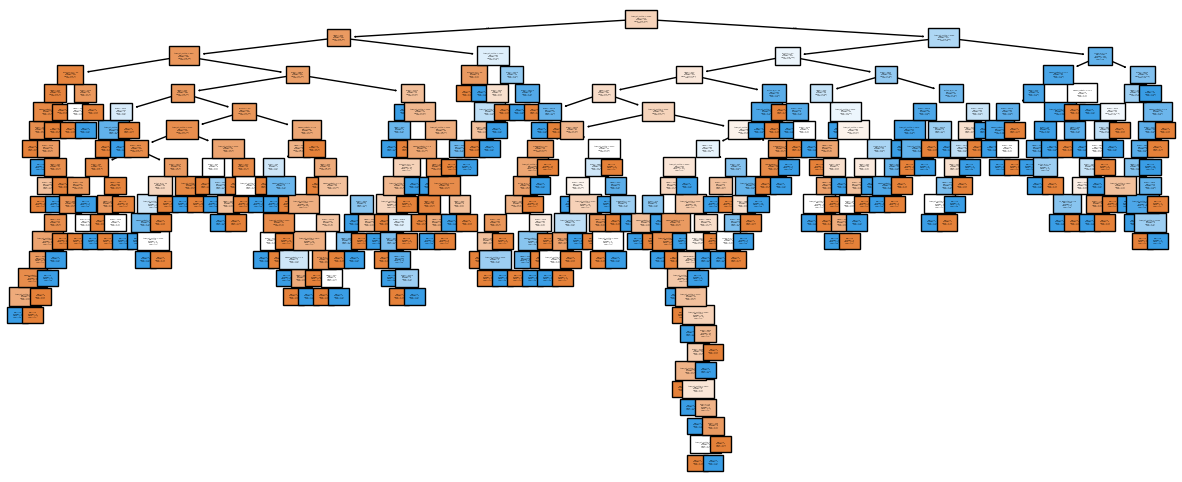

In [42]:
plt.figure(figsize=(15,6))
plot_tree(arvore, filled=True, class_names=['nao','sim'],fontsize=1, feature_names=nome_colunas);
# fiilded True : azul é não e laranja é sim
# class_names : 0 é não e 1 é sim
# ; para não aparecer textos

In [43]:
arvore.score(x_train, y_train)
# o modelo atingiu 100% de acuracia , pois decorou os padrões

1.0

In [44]:
arvore = DecisionTreeClassifier(max_depth = 3, random_state =5)
arvore.fit(x_train, y_train)
# max_depth > apenas 3 decisões

DecisionTreeClassifier(max_depth=3, random_state=5)

In [45]:
arvore.score(x_train,y_train)
# score de treino

0.7613038906414301

In [46]:
arvore.score(x_test,y_test)
# score de teste

0.7160883280757098

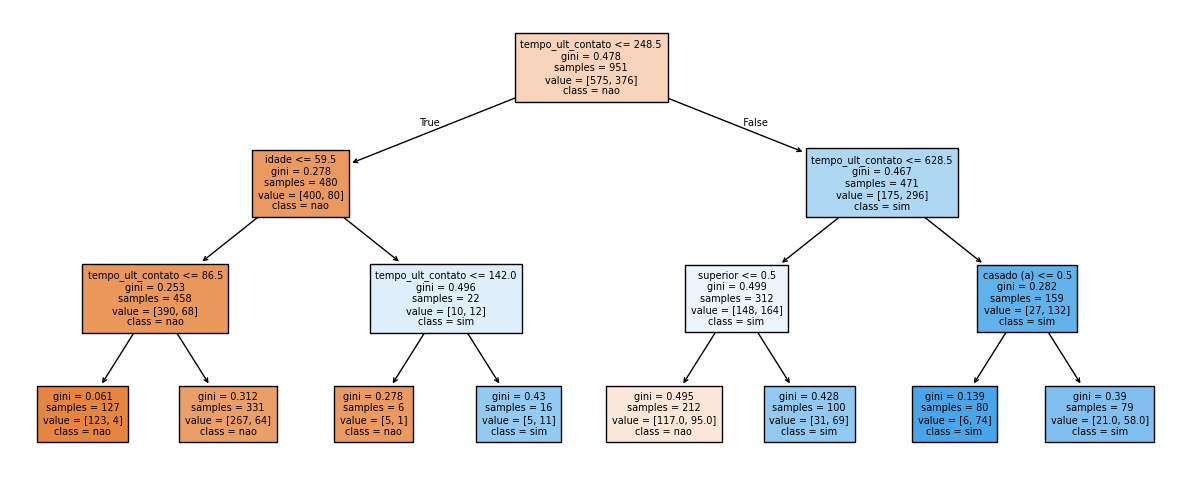

In [47]:
plt.figure(figsize=(15,6))
plot_tree(arvore, filled=True, class_names=['nao','sim'],fontsize=7, feature_names=nome_colunas);

# Algoritmo KNN.

In [48]:
from sklearn.preprocessing import MinMaxScaler

In [49]:
normalizacao = MinMaxScaler()
x_train_normalizado = normalizacao.fit_transform(x_train)

In [50]:
pd.DataFrame(x_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.205882,0.065564,0.123734,0.032258
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.147059,0.045792,0.396527,0.032258
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.076036,0.335022,0.000000
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.573529,0.062866,0.315123,0.000000
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.338235,0.148380,0.065847,0.129032
...,...,...,...,...,...,...,...,...,...,...,...,...
946,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.191176,0.044265,0.246382,0.129032
947,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.205882,0.028043,0.275687,0.032258
948,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.323529,0.042952,0.024964,0.129032
949,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.176471,0.042810,0.023878,0.000000


In [51]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
knn = KNeighborsClassifier()

In [53]:
knn.fit(x_train_normalizado, y_train)

KNeighborsClassifier()

In [54]:
x_test_normalizado = normalizacao.transform(x_test)

In [55]:
knn.score(x_test_normalizado,y_test)

0.6876971608832808

# Escolhendo o melhor modelo

In [56]:
print(f'Acurácia Dummy: {dummy.score(x_test, y_test)}')
print(f'\nAcurácia Árvore: {arvore.score(x_test, y_test)}')
print(f'\nAcurácia KNN: {knn.score(x_test_normalizado, y_test)}')

Acurácia Dummy: 0.6025236593059937

Acurácia Árvore: 0.7160883280757098

Acurácia KNN: 0.6876971608832808


In [57]:
import pickle

In [58]:
with open('modelo_onehotenc.pkl', 'wb') as arquivo:
    pickle.dump(one_hot, arquivo)

In [59]:
# modelo arvore
with open('modelo_arvore.pkl', 'wb') as arquivo:
    pickle.dump(arvore, arquivo)

# Teste com user

In [60]:
novo_dado = {
    'idade': [45],
    'estado_civil':['solteiro (a)'],
    'escolaridade':['superior'],
    'inadimplencia': ['nao'],
    'saldo': [23040],
    'fez_emprestimo': ['nao'],
    'tempo_ult_contato': [800],
    'numero_contatos': [4]
}

In [61]:
novo_dado = pd.DataFrame(novo_dado)
novo_dado

,idade,estado_civil,escolaridade,inadimplencia,saldo,fez_emprestimo,tempo_ult_contato,numero_contatos
0,45,solteiro (a),superior,nao,23040,nao,800,4


In [62]:
modelo_one_hot = pd.read_pickle('/content/modelo_onehotenc.pkl')
modelo_arvore = pd.read_pickle('/content/modelo_arvore.pkl')

In [63]:
novo_dado = modelo_one_hot.transform(novo_dado)
modelo_arvore.predict(novo_dado)
# cliente vai aderir ao programa de mkt

array([1])

# Exercício
1 - A primeira etapa em um projeto de Machine Learning é a obtenção de dados. A partir dessa obtenção, podemos fazer a leitura dos dados para se construir um modelo. Como tarefa inicial, faça a leitura da base de dados e verifique a presença de dados nulos. Além disso, remova a coluna 'id_cliente', uma vez que esse tipo de informação única para cada linha não é útil para uso em modelos de machine learning.

---

2 - Após a leitura dos dados, é importante conhecer os dados, checando inconsistências e entendendo o comportamento de cada uma das colunas. Nesta tarefa, faça uma análise exploratória utilizando gráficos para as variáveis categóricas da base de dados, incluindo a variável alvo churn. Para essas variáveis, pode ser utilizado gráficos de barras para fazer a contagem das categorias e fazer um agrupamento por cores de acordo com as categorias da variável alvo.

---

3 - Depois de explorar as variáveis categóricas, chegou a vez das variáveis numéricas. Construa gráficos de distribuição como boxplots ou histogramas para analisar o comportamento dos valores numéricos e checar se existem valores inconsistentes.

In [64]:
url = 'https://raw.githubusercontent.com/rayssasnt/machine-learning-ONE/refs/heads/main/churn.csv'
df = pd.read_csv(url,sep=',')

In [65]:
df

,id_cliente,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,15634602,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [66]:
df = df.drop(columns='id_cliente')

In [67]:
df

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   score_credito        10000 non-null  int64  
 1   pais                 10000 non-null  object 
 2   sexo_biologico       10000 non-null  object 
 3   idade                10000 non-null  int64  
 4   anos_de_cliente      10000 non-null  int64  
 5   saldo                10000 non-null  float64
 6   servicos_adquiridos  10000 non-null  int64  
 7   tem_cartao_credito   10000 non-null  int64  
 8   membro_ativo         10000 non-null  int64  
 9   salario_estimado     10000 non-null  float64
 10  churn                10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [69]:
px.histogram(df, x='sexo_biologico', text_auto=True, title='Evasão por sexo biologico',color='churn', barmode = 'group')

In [70]:
px.histogram(df, x='tem_cartao_credito', text_auto=True, title='Evasão por Pagamento em Cartão de Crédito',color='churn', barmode = 'group')

In [71]:
px.histogram(df, x='membro_ativo', text_auto=True, title='Evasão por Status do Cleinte',color='churn', barmode = 'group')

In [72]:
px.histogram(df, x='pais', text_auto=True, title='Evasão por País',color='churn', barmode = 'group')

In [73]:
px.box(df, x = 'score_credito', color = 'churn',title='Boxplot Score de Crédito')

In [74]:
px.box(df, x = 'idade', color = 'churn',title='Boxplot Idade de Clientes')

In [75]:
px.box(df, x = 'saldo', color = 'churn',title='Saldo de Clientes')

In [76]:
px.box(df, x = 'salario_estimado', color = 'churn',title='Boxplot Saldo Estimado')

In [77]:
px.box(df, x = 'anos_de_cliente', color = 'churn',title='Boxplot Anos de Cliente')

4- Para utilizar os dados nos algoritmos de Machine Learning, precisamos informar quais são as variáveis explicativas e qual é a variável alvo. Neste desafio, faça a separação da base de dados de churn entre as variáveis explicativas, armazenando em uma variável x e a variável alvo em y.


5- Variáveis categóricas que estejam em formato de texto não podem ser utilizadas diretamente nos modelos de Machine Learning. Neste desafio, faça a transformação das variáveis categóricas para o formato numérico usando o OneHotEncoder, utilizando o parâmetro drop='if_binary' caso alguma variável tenha apenas 2 categorias.


6- A variável alvo, como é do tipo categórica, também precisa passar por um tratamento similar às variáveis explicativas categóricas para que possa ser usada nos algoritmos. Nessa tarefa, utilize o método LabelEncoder para fazer a transformação da variável churn.

In [78]:
df.head()

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0


In [79]:
# var alvo
Y = df['churn']

# var explicativa
X = df.drop(columns='churn',axis=1)

In [80]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [81]:
col = X.columns
col

Index(['score_credito', 'pais', 'sexo_biologico', 'idade', 'anos_de_cliente',
       'saldo', 'servicos_adquiridos', 'tem_cartao_credito', 'membro_ativo',
       'salario_estimado'],
      dtype='object')

In [82]:
one_hot_ecoder = make_column_transformer((
    OneHotEncoder(drop='if_binary'),
                  ['pais', 'sexo_biologico','tem_cartao_credito', 'membro_ativo']),
    remainder='passthrough',
    sparse_threshold=0
)

In [83]:
X = one_hot_ecoder.fit_transform(X)

In [84]:
one_hot_ecoder.get_feature_names_out(col)
# novos nomes das colunas

array(['onehotencoder__pais_Alemanha', 'onehotencoder__pais_Espanha',
       'onehotencoder__pais_França',
       'onehotencoder__sexo_biologico_Mulher',
       'onehotencoder__tem_cartao_credito_1',
       'onehotencoder__membro_ativo_1', 'remainder__score_credito',
       'remainder__idade', 'remainder__anos_de_cliente',
       'remainder__saldo', 'remainder__servicos_adquiridos',
       'remainder__salario_estimado'], dtype=object)

In [85]:
pd.DataFrame(X,
             columns=one_hot_ecoder.get_feature_names_out(col))

,onehotencoder__pais_Alemanha,onehotencoder__pais_Espanha,onehotencoder__pais_França,onehotencoder__sexo_biologico_Mulher,onehotencoder__tem_cartao_credito_1,onehotencoder__membro_ativo_1,remainder__score_credito,remainder__idade,remainder__anos_de_cliente,remainder__saldo,remainder__servicos_adquiridos,remainder__salario_estimado
0,0.0,0.0,1.0,1.0,1.0,1.0,619.0,42.0,2.0,0.00,1.0,101348.88
1,0.0,1.0,0.0,1.0,0.0,1.0,608.0,41.0,1.0,83807.86,1.0,112542.58
2,0.0,0.0,1.0,1.0,1.0,0.0,502.0,42.0,8.0,159660.80,3.0,113931.57
3,0.0,0.0,1.0,1.0,0.0,0.0,699.0,39.0,1.0,0.00,2.0,93826.63
4,0.0,1.0,0.0,1.0,1.0,1.0,850.0,43.0,2.0,125510.82,1.0,79084.10
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,0.0,1.0,0.0,1.0,0.0,771.0,39.0,5.0,0.00,2.0,96270.64
9996,0.0,0.0,1.0,0.0,1.0,1.0,516.0,35.0,10.0,57369.61,1.0,101699.77
9997,0.0,0.0,1.0,1.0,0.0,1.0,709.0,36.0,7.0,0.00,1.0,42085.58
9998,1.0,0.0,0.0,0.0,1.0,0.0,772.0,42.0,3.0,75075.31,2.0,92888.52


In [86]:
# variavel alvo
label_econder_y = LabelEncoder()
Y = label_econder_y.fit_transform(Y)

7- A separação dos dados entre conjunto de treinamento e teste é essencial para compreender se um modelo está conseguindo aprender os padrões e generalizar para novos dados. Nesta tarefa, faça a divisão da base de dados entre treinamento e teste de forma estratificada.

8 - Um modelo de base é muito importante para definir um critério de comparação para modelos mais complexos. Nesta etapa, crie um modelo de base com o DummyClassifier e encontre a taxa de acerto com o método score.

9- A árvore de decisão é um algoritmo que faz as classificações a partir de decisões simples tomadas a partir dos dados. Temos que tomar certo cuidado para não utilizar uma profundidade muito grande, porque isso pode provocar um sobreajuste do modelo aos dados de treinamento. Neste desafio, crie um modelo de árvore de decisão com o parâmetro max_depth=4, avalie o desempenho do modelo nos dados de teste e visualize as decisões da árvore usando o método plot_tree.

In [87]:
x_treino , x_teste , y_treino , y_teste = train_test_split(X,Y , random_state=5, stratify=Y)

In [88]:
# modelo base
dummy_2 = DummyClassifier() # inicia
dummy_2.fit(x_treino, y_treino) #treina o modelo
dummy_2.score(x_teste,y_teste) # avalia o modelo

0.7964

In [89]:
# arvore de decisão
arvore_2 = DecisionTreeClassifier(max_depth=4,random_state=5)
arvore_2.fit(x_treino,y_treino)
arvore_2.score(x_teste,y_teste)

0.8464

In [90]:
col

Index(['score_credito', 'pais', 'sexo_biologico', 'idade', 'anos_de_cliente',
       'saldo', 'servicos_adquiridos', 'tem_cartao_credito', 'membro_ativo',
       'salario_estimado'],
      dtype='object')

In [91]:
idx_col = ['score_credito', 'pais', 'sexo_biologico', 'idade', 'anos_de_cliente',
       'saldo', 'servicos_adquiridos', 'tem_cartao_credito', 'membro_ativo',
       'salario_estimado']

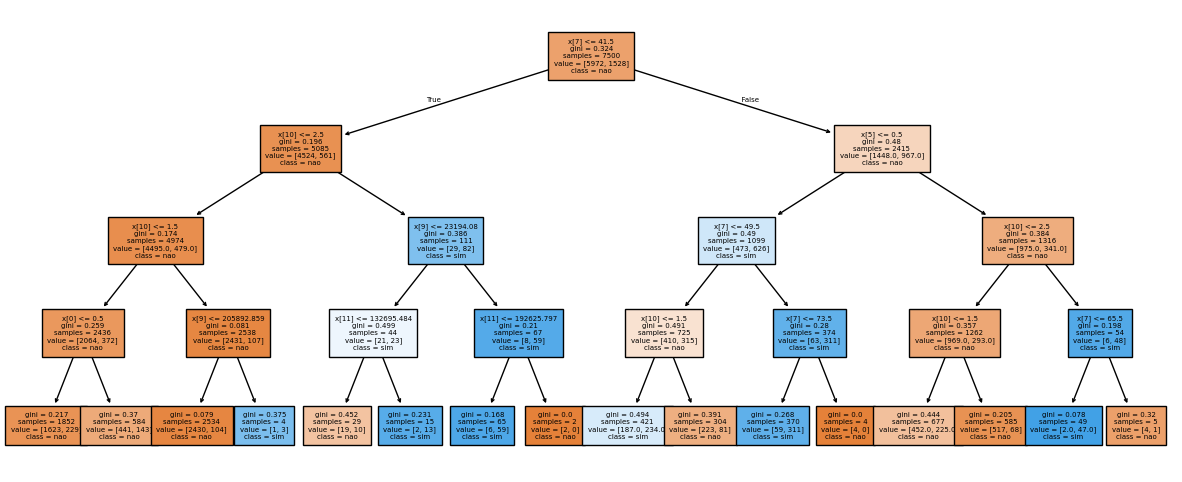

In [92]:
plt.figure(figsize=(15,6))
plot_tree(arvore_2, filled=True, class_names=['nao','sim'],fontsize=5);

In [93]:
df

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado,churn
0,619,França,Mulher,42,2,0.00,1,1,1,101348.88,1
1,608,Espanha,Mulher,41,1,83807.86,1,0,1,112542.58,0
2,502,França,Mulher,42,8,159660.80,3,1,0,113931.57,1
3,699,França,Mulher,39,1,0.00,2,0,0,93826.63,0
4,850,Espanha,Mulher,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,França,Homem,39,5,0.00,2,1,0,96270.64,0
9996,516,França,Homem,35,10,57369.61,1,1,1,101699.77,0
9997,709,França,Mulher,36,7,0.00,1,0,1,42085.58,1
9998,772,Alemanha,Homem,42,3,75075.31,2,1,0,92888.52,1


In [94]:
# modelo arvore
with open('modelo_arvore2.pkl', 'wb') as arquivo:
    pickle.dump(arvore_2, arquivo)

In [95]:
# modelo one hot
with open('modelo_hot2.pkl', 'wb') as arquivo:
    pickle.dump(one_hot_ecoder, arquivo)

In [96]:
teste = {
    'score_credito':[800],
    'pais':['França'],
    'sexo_biologico':['Mulher'],
    'idade':[41],
    'anos_de_cliente':[10],
    'saldo':[25000],
    'servicos_adquiridos':[3],
    'tem_cartao_credito':[1],
    'membro_ativo':[1],
    'salario_estimado':[1000090],
}

dado_teste = pd.DataFrame(teste)

In [97]:
dado_teste

,score_credito,pais,sexo_biologico,idade,anos_de_cliente,saldo,servicos_adquiridos,tem_cartao_credito,membro_ativo,salario_estimado
0,800,França,Mulher,41,10,25000,3,1,1,1000090


In [98]:
modelo_hot = pd.read_pickle('/content/modelo_hot2.pkl')

In [99]:
modelo_arvore2 = pd.read_pickle('/content/modelo_arvore2.pkl')

In [100]:
dado_teste = modelo_hot.transform(dado_teste)

In [102]:
modelo_arvore2.predict(dado_teste)
# 0 não
# 1 sim

array([0])